In [10]:
import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) # Agrega la raíz al path para poder importar src/

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.config import SEED, DATA_RAW, DATA_PROC, SPLITS_CSV, ROOT, PROC_SPLITS, CLASES
random.seed(SEED)

from src.exploracion import contar_dataset, mostrar_muestras, balance_clases, reporte_dimensiones
from src.data import build_splits_csv, preprocess_dataset

# Clasificación: Imágenes Reales vs. generadas por IA
## Fase 1 - EDA y Preprocesamiento

Este notebook contiene las primeras dos etapas del pipeline:

1. **Exploración del dataset crudo**: estructura, balance de clases y distribución de dimensiones.
2. **Preparación de datos**: división train/val/test y redimensionado a 224x224 px.

## 1. Estructura del dataset

El dataset viene organizado en dos carpetas: `raw/train/` (48 000 imágenes) y `raw/test/` (12 000 imágenes), cada una con subcarpetas `real/` y `fake/`.

In [2]:
conteo = contar_dataset(DATA_RAW)

train/real :  24000 imágenes
train/fake :  24000 imágenes
test/real :   6000 imágenes
test/fake :   6000 imágenes

TOTAL: 60000 imágenes


## 2. Inspección visual

Muestras aleatorias de imágenes reales (fila superior) vs. generadas por IA (fila inferior).

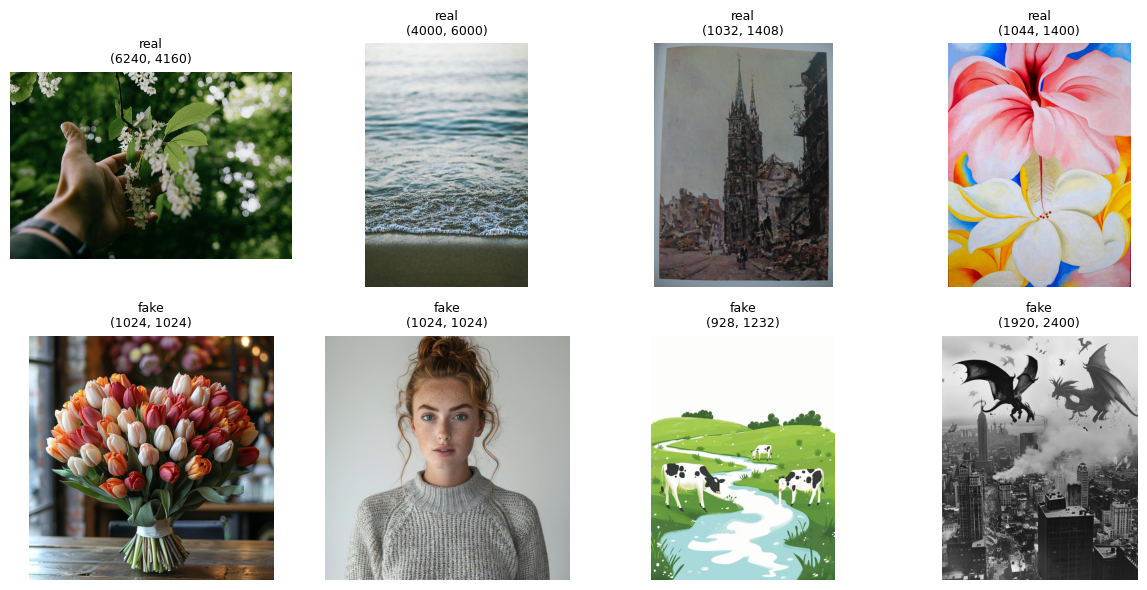

In [3]:
mostrar_muestras(conteo, split="train", n=4)

## 3. Balance de clases

Verificamos que la proporción real/fake sea 50/50, ya que un dataset desbalanceado sesga al modelo hacia la clase mayoritaria.

In [4]:
balance_clases(conteo)


train:
  real:  24000 (50.0%)
  fake:  24000 (50.0%)

test:
  real:   6000 (50.0%)
  fake:   6000 (50.0%)


Está perfectamente balanceado

## 4. Distribución de dimensiones

Las imágenes del dataset vienen en tamaños muy distintos. Esto es importante porque los modelos requieren un input de tamaño fijo, así que hay que redimensionar todo a 224x224px en el preprocesamiento.

Se redimensiona a 224x224px porque es el tamaño de entrada estándar de ResNet50 (y de la mayoría de las arquitecturas preentrenadas en ImageNet), lo que nos permite reutilizar los pesos preentrenados sin modificar la arquitectura más adelante.

In [5]:
reporte_dimensiones(conteo, n=99999)


train/real - tamaños más comunes (sobre muestra):
  (1080, 1620): 3322
  (1080, 720): 1700
  (1080, 1350): 666
  (6000, 4000): 551
  (4000, 6000): 468

train/fake - tamaños más comunes (sobre muestra):
  (1024, 1024): 11474
  (1456, 816): 1890
  (2048, 2048): 1334
  (512, 512): 694
  (896, 1344): 586

test/real - tamaños más comunes (sobre muestra):
  (1080, 1620): 907
  (1080, 720): 409
  (1080, 1350): 179
  (6000, 4000): 125
  (4000, 6000): 104

test/fake - tamaños más comunes (sobre muestra):
  (1024, 1024): 2894
  (1456, 816): 473
  (2048, 2048): 322
  (512, 512): 174
  (816, 1456): 154


### Observaciones

Notamos que las imágenes **reales** son mayormente rectangulares (fotos de celular y cámara), mientras que las **generadas por IA** son mayormente cuadradas (1024x1024, 2048x2048), que son resoluciones típicas de generadores como Stable Diffusion o DALL-E.

Al redimensionar todo a 224x224 perdemos esta diferencia de aspecto ratio. El modelo tendrá que aprender señales más sutiles como texturas y coherencia en las imágenes.

## 5. Split del dataset y preprocesamiento

Se divide el dataset en **80% train / 10% val / 10% test**:
- `raw/train/` completo (48000 imgs) $\rightarrow$ **train**
- `raw/test/` partido 50/50 estratificado $\rightarrow$ **val** y **test** (6000 c/u)

Luego se redimensionan todas las imágenes a 224x224 px y se las guarda en `data/processed/`.

In [6]:
build_splits_csv()
preprocess_dataset()

train:  48000 imgs  (24000 real / 24000 fake)
val  :   6000 imgs  (3000 real / 3000 fake)
test :   6000 imgs  (3000 real / 3000 fake)


Procesando imágenes:   0%|          | 39/60000 [00:09<2:50:21,  5.87it/s]


Skip imagen corrupta: 0038.jpg (image file is truncated (2 bytes not processed))


Procesando imágenes:   6%|▌         | 3303/60000 [04:13<3:44:40,  4.21it/s]


Skip imagen corrupta: 12094.jpg (image file is truncated (2 bytes not processed))


...


Skip imagen corrupta: 5325.jpg (image file is truncated (2 bytes not processed))


Procesando imágenes:  95%|█████████▍| 56745/60000 [52:35<01:30, 36.07it/s]


Skip imagen corrupta: 5879.jpg (image file is truncated)


Procesando imágenes: 100%|██████████| 60000/60000 [55:41<00:00, 17.96it/s]


Se eliminaron 12 imágenes corruptas del CSV.
Listo. 59988 imágenes en /Users/lautarocaminoa/Documents/UdeSA/Materias/ML/ProyectoFinal/PF_ML_Krinisky_Caminoa/data/processed


## 6. Verificación del preprocesamiento

Se chequea que el split haya resultado balanceado y que las imágenes procesadas se vean correctas comparadas con los originales.

In [7]:
df = pd.read_csv(SPLITS_CSV)
print("Distribución del split:")
for split in PROC_SPLITS:
    sub = df[df["split"] == split]
    for clase in CLASES:
        n = len(sub[sub["label"] == clase])
        print(f"  - {split}/{clase}: {n}")
    print(f"  Total {split}: {len(sub)}\n")

Distribución del split:
  - train/real: 23993
  - train/fake: 23998
  Total train: 47991

  - val/real: 3000
  - val/fake: 3000
  Total val: 6000

  - test/real: 2997
  - test/fake: 3000
  Total test: 5997



**Nota:** El total es levemente menor al esperado (47991 en train en vez de 48000; 5997 en test en vez de 6 000) ya que durante el preprocesamiento se descartaron 12 imágenes corruptas. El desbalance es menor al 0.01%, por lo que no afecta el entrenamiento.

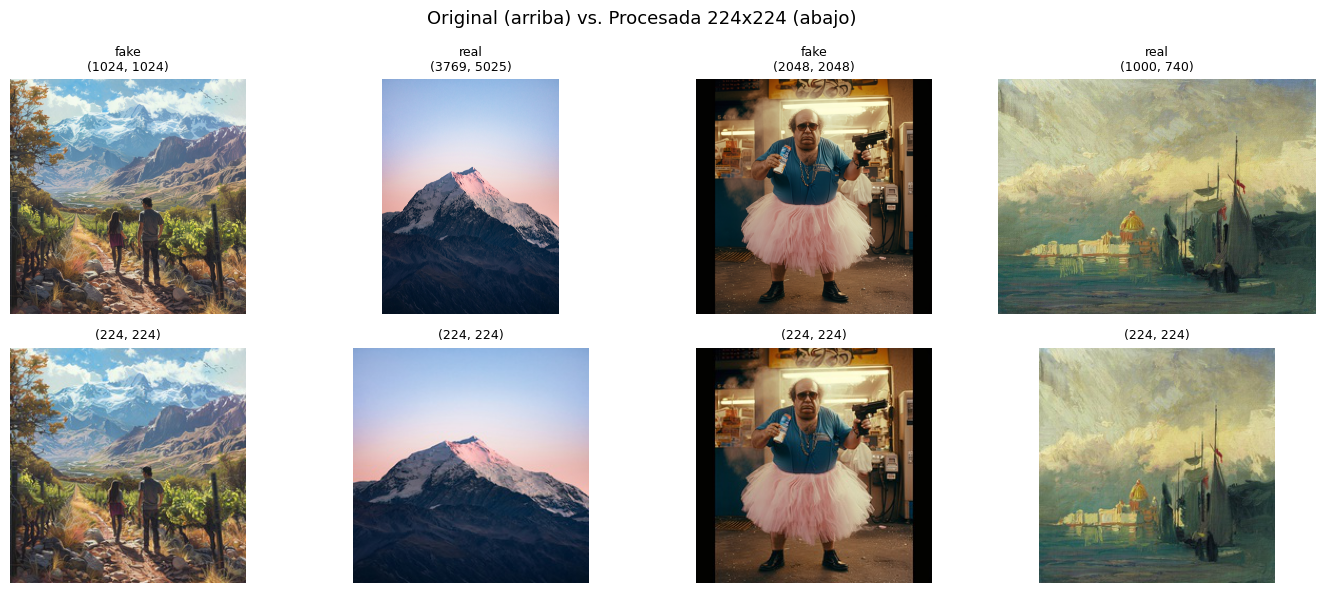

In [ ]:
muestra = df[df["split"] == "train"].sample(4, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Original (arriba) vs. Procesada 224x224 (abajo)", fontsize=13)

for col, (_, row) in enumerate(muestra.iterrows()):
    ruta_original = ROOT / row["path"]
    ruta_procesada = DATA_PROC / row["split"] / row["label"] / (Path(row["path"]).stem + ".jpg")

    img_orig = Image.open(ruta_original)
    img_proc = Image.open(ruta_procesada)

    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(f"{row['label']}\n{img_orig.size}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_proc)
    axes[1, col].set_title(f"{img_proc.size}", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()